# 卷积层里的多输入多输出通道

## 多个输入通道


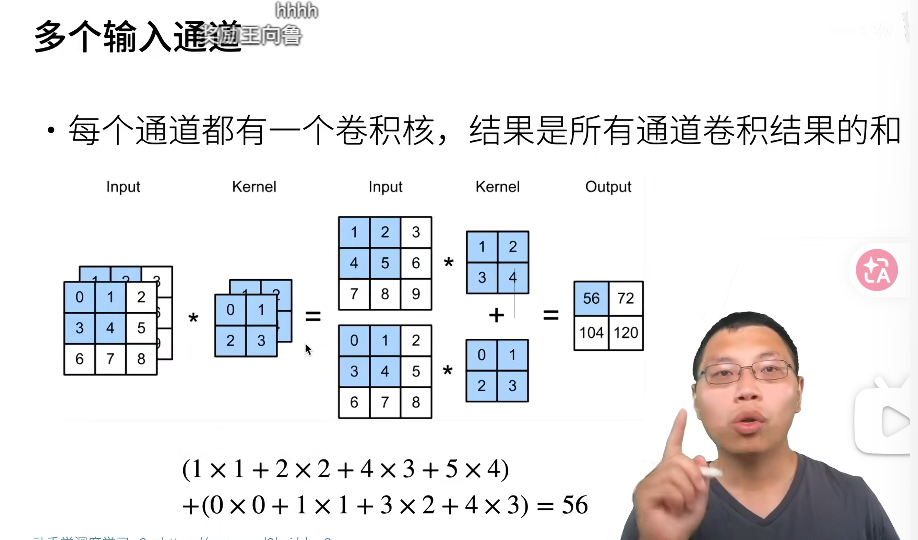

每个通道卷积核不同，结果时所有通道卷积结果的和

多输入-单输出

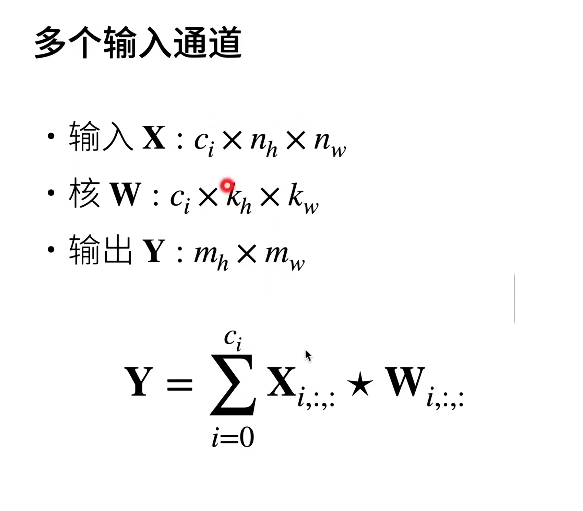


## 多个输出通道

输入通道的个数=卷积核通道的个数  

卷积核的个数 = 输出通道的个数


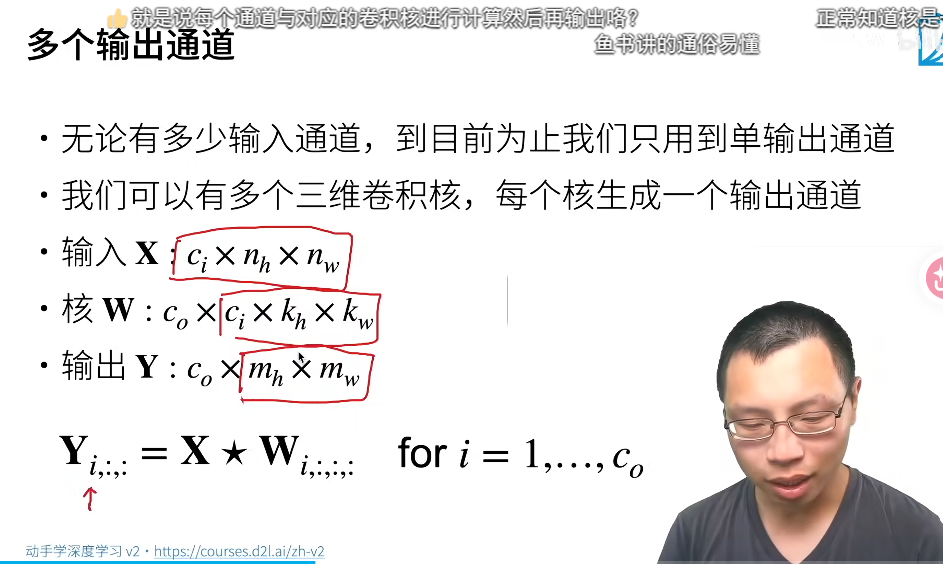

ci：输入通道的卷积核层数，如彩色图片的通道数=3

co：输出通道的卷积核个数，为了提取出不同的特征，特征数。 

两者无相关性

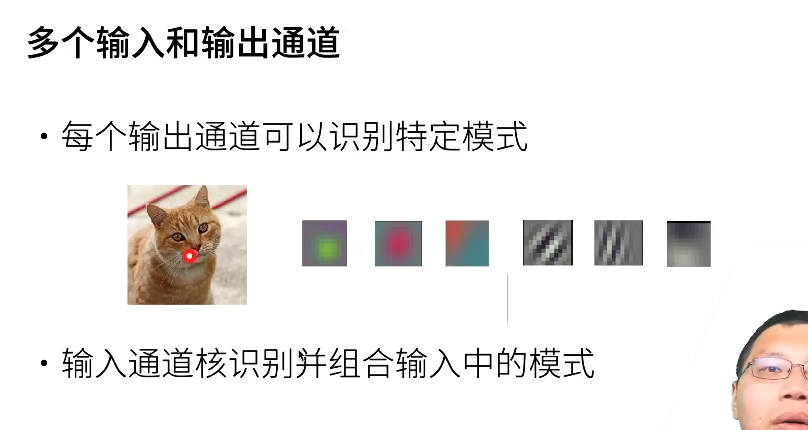

卷积核的第一个维度就是提取不同的特征数

卷积核的第二个维度对应的是输入通道的个数，即提取某个特征在多个输入通道上的所有特征

## 1×1 卷积层 

不识别空间模式，只是融合通道



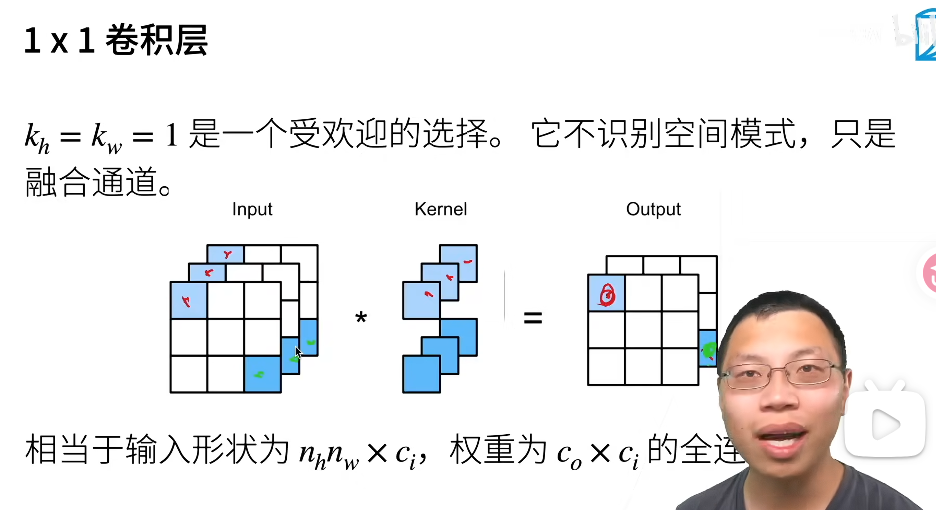

input 通道数为 3 

kernel 通道数为 2×3

output 通道数为 2

## 二维卷积层——多输入多输出

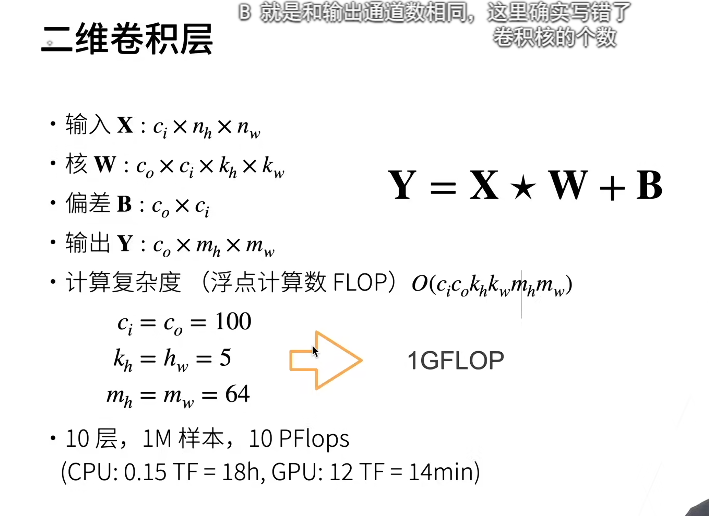

输出$m_w*m_h$个点,有$c_o$通道，实际有$C_o*m_h*m_w$个点

每个点由卷积核$k_w*k_h$乘加操作, 有$c_i$个通道, $C_i*K_w*K_h$次乘法操作

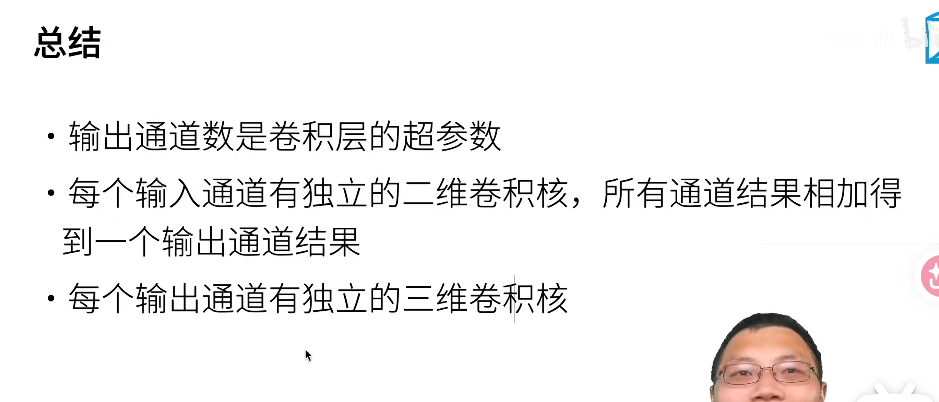

“输入通道数 × 输出通道数”个 2D 卷积核 —— 且它们每一个都不一样。

每个通道的卷积核是不一样的，不同通道的卷积核大小是一样的（计算和）

## 代码

In [1]:
import torch
from d2l import torch as d2l

多输入互相关，输入通道和卷积核匹配，分别相乘再求总和

In [2]:
def corr2d_multi_in(X, K):
    # 先遍历“X”和“K”的第0个维度（通道维度），再把它们加在⼀起
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

In [3]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
    [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])
corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

多输出通道，在卷积核第一个维度上堆叠结果

In [4]:
def corr2d_multi_in_out(X, K):
    # 迭代“K”的第0个维度，每次都对输⼊“X”执⾏互相关运算。
    # 最后将所有结果都叠加在⼀起
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [5]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

torch.Size([3, 2, 2, 2])

In [6]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

1×1 卷积

In [7]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    # 全连接层中的矩阵乘法
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

In [8]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6